In [4]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3" 

import logging
import tensorflow as tf
tf.get_logger().setLevel(logging.ERROR)

import absl.logging
absl.logging.set_verbosity(absl.logging.ERROR)

import shutil
import random
from pathlib import Path

import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.metrics import classification_report, confusion_matrix

In [5]:
import numpy
print(numpy.__version__)

1.24.3


In [6]:
import tensorflow as tf
print(tf.__version__)                              # doit afficher 2.10.x
print(tf.config.list_physical_devices('GPU'))      # doit lister ta RTX 3060

2.13.0
[]


In [7]:
SOURCE_DIR  = Path("Tumordataset-2")
WORK_ROOT   = Path("dataset_split-2") 
CLASS_NAMES = ["glioma", "meningioma", "notumor", "pituitary"] 

SPLIT    = {"train": 0.80, "valid": 0.01, "test": 0.19} 
IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff"}

IMG_SIZE   = (224, 224)
BATCH_SIZE = 32
EPOCHS     = 15
SEED       = 42

In [8]:
def split_dataset():
    if WORK_ROOT.exists():
        print("skip,", WORK_ROOT, "existe deja.")
        return
    rng = random.Random(SEED)
    for cls in CLASS_NAMES:
        src = SOURCE_DIR / cls
        files = [p for p in src.iterdir() if p.suffix.lower() in IMG_EXTS]
        rng.shuffle(files)
        n = len(files)
        n_train = int(n * SPLIT["train"])
        n_valid = int(n * SPLIT["valid"])
        buckets = {
            "train": files[:n_train],
            "valid": files[n_train:n_train + n_valid],
            "test":  files[n_train + n_valid:],
        }
        for split, items in buckets.items():
            out = WORK_ROOT / split / cls
            out.mkdir(parents=True, exist_ok=True)
            for p in items:
                shutil.copy(p, out / p.name)
        print(cls, "->", n, "images :", {k: len(v) for k, v in buckets.items()})
    print("Decoupage termine sous", WORK_ROOT)


split_dataset()

skip, dataset_split-2 existe deja.


In [9]:
def load_split(name, shuffle):
    return tf.keras.utils.image_dataset_from_directory(
        WORK_ROOT / name,
        labels="inferred",
        label_mode="int",
        class_names=CLASS_NAMES,
        color_mode="rgb",
        image_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        shuffle=shuffle,
        seed=SEED,
    )

train_ds = load_split("train", shuffle=True)
val_ds   = load_split("valid", shuffle=False)
test_ds  = load_split("test",  shuffle=False)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)
test_ds  = test_ds.prefetch(AUTOTUNE)

Found 11377 files belonging to 4 classes.
Found 141 files belonging to 4 classes.
Found 2705 files belonging to 4 classes.


In [10]:
data_augmentation = models.Sequential([
    layers.RandomRotation(0.05),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
], name="augmentation")

In [11]:
def build_cnn(input_shape=(*IMG_SIZE, 3), num_classes=len(CLASS_NAMES)):
    inputs = layers.Input(shape=input_shape)

    x = data_augmentation(inputs)
    x = layers.Rescaling(1.0 / 255)(x)

    # 32 filtre
    x = layers.Conv2D(32, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    # 64 filtres
    x = layers.Conv2D(64, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    # 128 filtre
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    # 128 filtres
    x = layers.Conv2D(128, 3, padding="same", activation="relu")(x)
    x = layers.BatchNormalization(momentum=0.9)(x)
    x = layers.MaxPooling2D()(x)

    # Classification
    x = layers.GlobalAveragePooling2D()(x)    
    x = layers.Dropout(0.4)(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.3)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    return models.Model(inputs, outputs, name="cnn_from_scratch")


model = build_cnn()
model.summary()

Model: "cnn_from_scratch"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 augmentation (Sequential)   (None, 224, 224, 3)       0         
                                                                 
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 batch_normalization (Batch  (None, 224, 224, 32)      128       
 Normalization)                                                  
                                                                 
 max_pooling2d (MaxPooling2  (None, 112, 112, 32)      0         
 D)                                               

In [15]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

cb = [
    callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True),
    callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=4, min_lr=1e-6),
    callbacks.ModelCheckpoint("best_cnn.h5", monitor="val_accuracy", save_best_only=True),
]

In [16]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb,
)
model.save("best_cnn.h5")

Epoch 1/15
356/356 [==============================] - 407s 1s/step - loss: 0.6619 - accuracy: 0.7419 - val_loss: 1.1858 - val_accuracy: 0.6028 - lr: 1.0000e-04
Epoch 2/15


C:\Users\FA706\AppData\Roaming\Python\Python39\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


356/356 [==============================] - 412s 1s/step - loss: 0.5757 - accuracy: 0.7819 - val_loss: 1.2573 - val_accuracy: 0.6312 - lr: 1.0000e-04
Epoch 3/15
356/356 [==============================] - 427s 1s/step - loss: 0.5250 - accuracy: 0.8028 - val_loss: 1.5025 - val_accuracy: 0.6241 - lr: 1.0000e-04
Epoch 4/15
356/356 [==============================] - 398s 1s/step - loss: 0.4777 - accuracy: 0.8209 - val_loss: 0.9818 - val_accuracy: 0.6738 - lr: 1.0000e-04
Epoch 5/15
356/356 [==============================] - 396s 1s/step - loss: 0.4447 - accuracy: 0.8392 - val_loss: 0.7780 - val_accuracy: 0.7376 - lr: 1.0000e-04
Epoch 6/15
356/356 [==============================] - 397s 1s/step - loss: 0.4311 - accuracy: 0.8423 - val_loss: 1.5076 - val_accuracy: 0.6241 - lr: 1.0000e-04
Epoch 7/15
356/356 [==============================] - 397s 1s/step - loss: 0.4014 - accuracy: 0.8515 - val_loss: 1.5369 - val_accuracy: 0.6170 - lr: 1.0000e-04
Epoch 8/15
356/356 [==============================]

In [17]:
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy :", round(test_acc, 3))

y_true, y_pred = [], []
for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    y_pred.extend(np.argmax(probs, axis=1))
    y_true.extend(labels.numpy())

print()
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))

85/85 [==============================] - 20s 229ms/step - loss: 0.3505 - accuracy: 0.8750
Test accuracy : 0.875

              precision    recall  f1-score   support

      glioma       0.87      0.92      0.90       651
  meningioma       0.93      0.58      0.72       655
     notumor       0.90      1.00      0.95       722
   pituitary       0.82      0.98      0.90       677

    accuracy                           0.88      2705
   macro avg       0.88      0.87      0.86      2705
weighted avg       0.88      0.88      0.87      2705



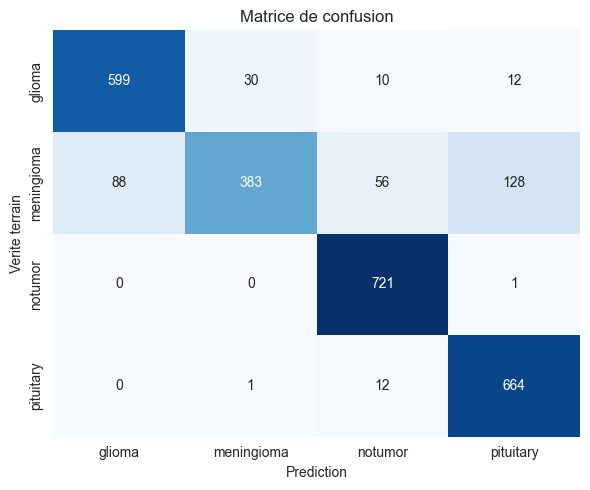

In [18]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm, annot=True, fmt="d", cmap="Blues",
    xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    cbar=False,
)
plt.xlabel("Prediction")
plt.ylabel("Verite terrain")
plt.title("Matrice de confusion")
plt.tight_layout()
plt.show()

Embedding de dimension : 128


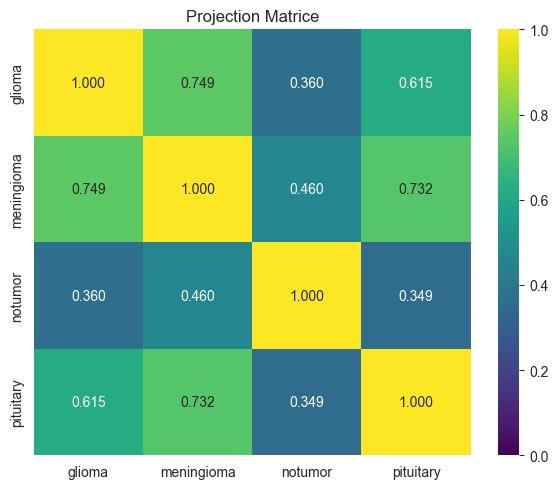

In [19]:
from tensorflow.keras import Model
from sklearn.metrics.pairwise import cosine_similarity

gap_layer = None
for l in model.layers:
    if "global_average_pooling" in l.name:
        gap_layer = l
        break

feature_extractor = Model(inputs=model.input, outputs=gap_layer.output)
print("Embedding de dimension :", gap_layer.output.shape[-1])

embeddings, labels_all = [], []
for images, labels in test_ds:
    feats = feature_extractor.predict(images, verbose=0) 
    embeddings.append(feats)
    labels_all.append(labels.numpy())

embeddings = np.concatenate(embeddings)
labels_all = np.concatenate(labels_all)

centroids = np.stack([
    embeddings[labels_all == c].mean(axis=0)
    for c in range(len(CLASS_NAMES))
])

S = cosine_similarity(centroids)

plt.figure(figsize=(6, 5))
sns.heatmap(S, annot=True, fmt=".3f", cmap="viridis",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
            vmin=0, vmax=1)
plt.title("Projection Matrice")
plt.tight_layout()
plt.show()

[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2705 samples in 0.000s...
[t-SNE] Computed neighbors for 2705 samples in 2.017s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2705
[t-SNE] Computed conditional probabilities for sample 2000 / 2705
[t-SNE] Computed conditional probabilities for sample 2705 / 2705
[t-SNE] Mean sigma: 1.204939
[t-SNE] KL divergence after 250 iterations with early exaggeration: 69.587654
[t-SNE] KL divergence after 1000 iterations: 0.881370


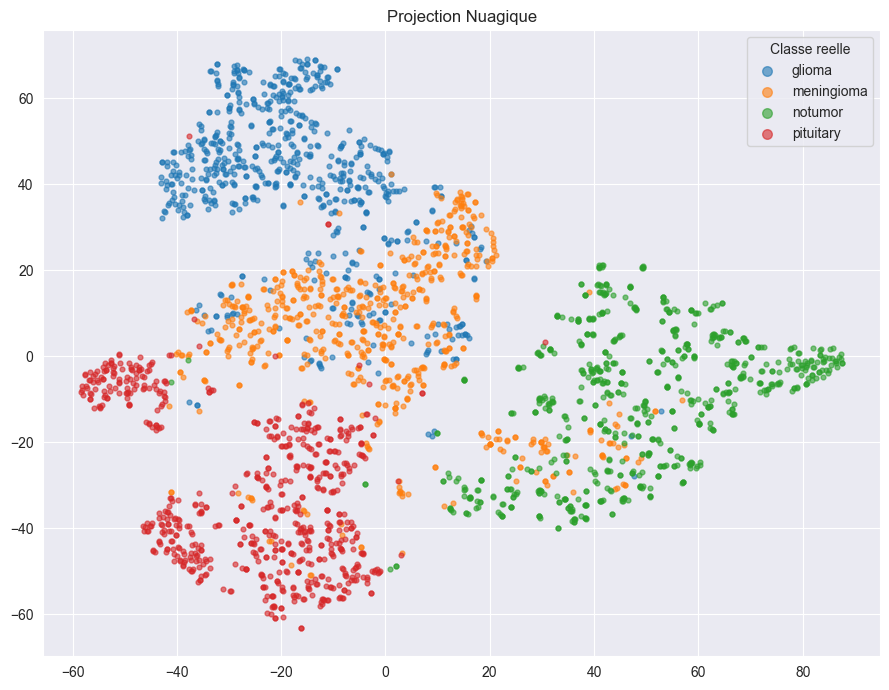

In [20]:
from sklearn.manifold import TSNE

tsne = TSNE(
    n_components=2,
    perplexity=30,
    init="pca",
    learning_rate="auto",
    random_state=42,
    verbose=1,
)
proj = tsne.fit_transform(embeddings) 

plt.figure(figsize=(9, 7))
palette = sns.color_palette("tab10", len(CLASS_NAMES))
for c in range(len(CLASS_NAMES)):
    mask = labels_all == c
    plt.scatter(
        proj[mask, 0], proj[mask, 1],
        s=12, alpha=0.6, color=palette[c], label=CLASS_NAMES[c],
    )

plt.legend(title="Classe reelle", markerscale=2)
plt.title("Projection Nuagique")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

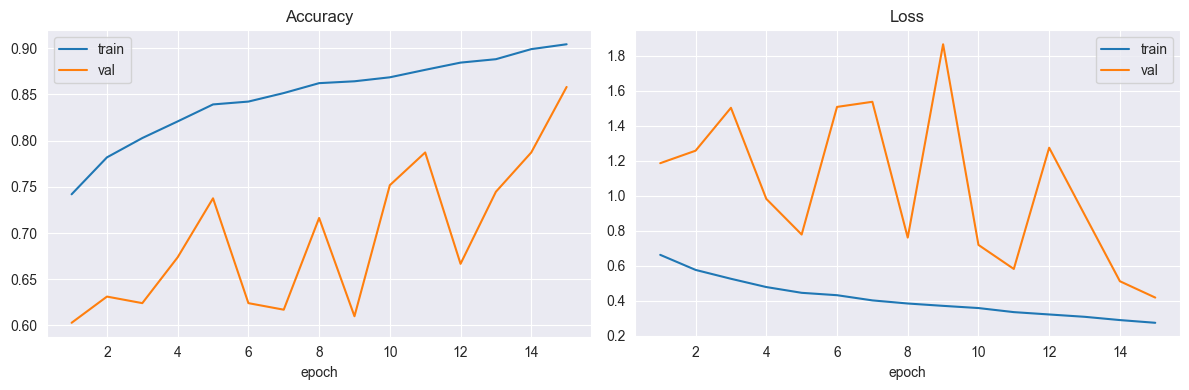

In [21]:
hist = history.history
epochs_range = list(range(1, len(hist["loss"]) + 1))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(x=epochs_range, y=hist["accuracy"], label="train", ax=ax1)
sns.lineplot(x=epochs_range, y=hist["val_accuracy"], label="val", ax=ax1)
ax1.set_title("Accuracy")
ax1.set_xlabel("epoch")

sns.lineplot(x=epochs_range, y=hist["loss"], label="train", ax=ax2)
sns.lineplot(x=epochs_range, y=hist["val_loss"], label="val", ax=ax2)
ax2.set_title("Loss")
ax2.set_xlabel("epoch")

plt.tight_layout()
plt.show()

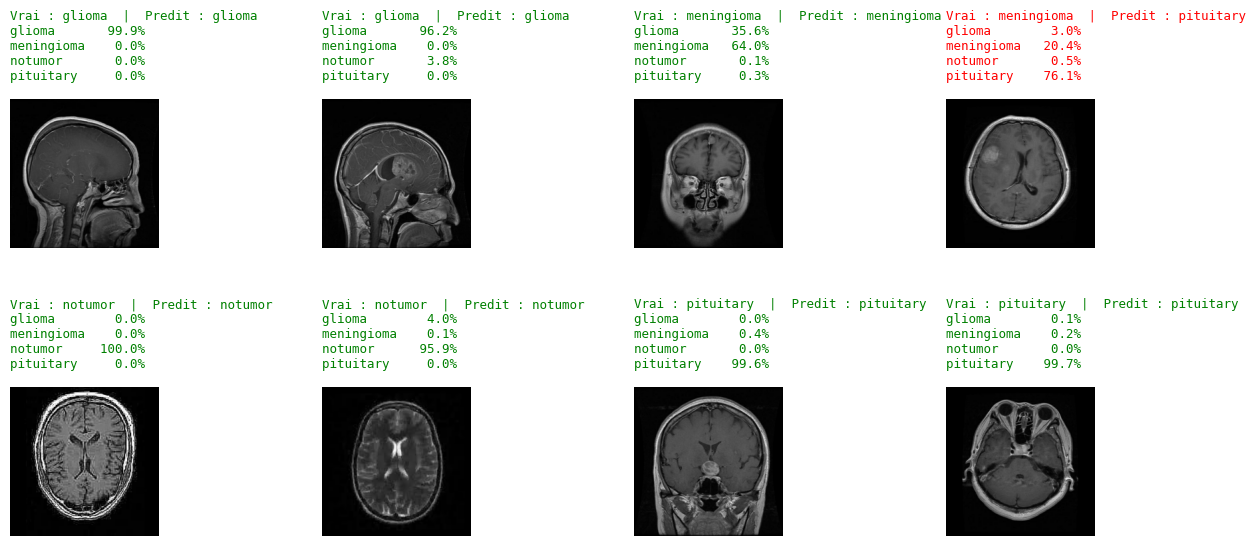

In [22]:
PER_CLASS = 2

buckets = {c: [] for c in range(len(CLASS_NAMES))}
for images, labels in test_ds:
    for img, lab in zip(images, labels):
        lab = int(lab.numpy())
        if len(buckets[lab]) < PER_CLASS:
            buckets[lab].append(img)
    if all(len(v) >= PER_CLASS for v in buckets.values()):
        break

sel_images, sel_labels = [], []
for c in range(len(CLASS_NAMES)):
    for img in buckets[c]:
        sel_images.append(img)
        sel_labels.append(c)

sel_images = tf.stack(sel_images)
probs = model.predict(sel_images, verbose=0)

ncols = len(CLASS_NAMES)
nrows = PER_CLASS
fig, axes = plt.subplots(nrows, ncols, figsize=(3.5 * ncols, 5.5 * nrows))
fig.patch.set_facecolor("white")
axes = axes.flatten()

for i in range(len(sel_images)):
    ax = axes[i]
    ax.imshow(sel_images[i].numpy().astype("uint8"))
    ax.axis("off")

    vrai = CLASS_NAMES[sel_labels[i]]
    pred_id = int(np.argmax(probs[i]))
    pred = CLASS_NAMES[pred_id]
    ok = (pred_id == sel_labels[i])
    couleur = "green" if ok else "red"

    entete = f"Vrai : {vrai}  |  Predit : {pred}"
    detail = "\n".join(
        f"{CLASS_NAMES[c]:<11} {probs[i][c] * 100:5.1f}%"
        for c in range(len(CLASS_NAMES))
    )

    ax.annotate(
        entete + "\n" + detail,
        xy=(0, 1), xycoords="axes fraction",
        xytext=(0, 12), textcoords="offset points",
        ha="left", va="bottom",
        color=couleur, fontsize=9, family="monospace",
    )

for j in range(len(sel_images), len(axes)):
    axes[j].axis("off")

plt.subplots_adjust(hspace=0.9, wspace=1.1, top=0.45, bottom=0.05)
plt.show()